In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#importing dataset
df=pd.read_csv("house_price_prediction.csv")
display(df)

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
0,1360,5,4,3,1986,830739
1,4272,5,4,3,2018,1783490
2,3592,2,2,3,1982,1240886
3,966,4,2,2,1991,592593
4,4926,1,4,2,1986,1725758
...,...,...,...,...,...,...
1995,4994,5,4,3,2002,2023123
1996,3046,5,2,1,2019,1256903
1997,1062,5,1,2,2023,621350
1998,4062,3,1,2,2001,1415670


In [3]:
df=df.drop_duplicates()

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(2000, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       2000 non-null   int64
 1   Bedrooms   2000 non-null   int64
 2   Bathrooms  2000 non-null   int64
 3   Floors     2000 non-null   int64
 4   YearBuilt  2000 non-null   int64
 5   Price      2000 non-null   int64
dtypes: int64(6)
memory usage: 93.9 KB


In [7]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2.000000e+03
mean,2786.209500,3.003500,2.55250,1.993500,2001.525000,1.126200e+06
std,1295.146799,1.424606,1.10899,0.809188,12.648532,4.062553e+05
min,501.000000,1.000000,1.00000,1.000000,1980.000000,2.135620e+05
25%,1653.000000,2.000000,2.00000,1.000000,1991.000000,7.830798e+05
50%,2833.000000,3.000000,3.00000,2.000000,2001.000000,1.141231e+06
75%,3887.500000,4.000000,4.00000,3.000000,2013.000000,1.459170e+06
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,2.023123e+06


In [8]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
0,1360,5,4,3,1986,830739
1,4272,5,4,3,2018,1783490
2,3592,2,2,3,1982,1240886
3,966,4,2,2,1991,592593
4,4926,1,4,2,1986,1725758


In [9]:
df.dropna(inplace = True)

In [10]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Price        0
dtype: int64

In [11]:
X = df[['Area']]
y = df['Price']

In [12]:
print(X.isnull().sum())
print(y.isnull().sum())

Area    0
dtype: int64
0


In [13]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [14]:
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge , Lasso
# model = Ridge(alpha=1.0, max_iter = 100)
# model = Lasso(alpha =0.1)
model = LinearRegression()
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
#prediction
y_pred = model.predict(X_test)
y_pred

array([ 473520.20822578, 1451419.48840793,  766313.50806313,
        798778.67187929, 1059410.22064642, 1258145.56924069,
       1059713.63339237, 1231445.24759749,  820017.56409547,
       1528182.91313213, 1225983.81817047, 1195945.95632187,
       1432607.89815931, 1064568.2373275 , 1369801.45974861,
       1008133.46658165, 1717815.87934802, 1244795.40841909,
        682268.17743624,  603077.45074449, 1281811.76342443,
        724745.96186861, 1518170.29251593, 1674124.44393188,
        890712.73390076, 1794882.71681817,  725352.7873605 ,
       1083379.82757611,  756300.88744693,  896780.98881967,
       1659560.6321265 ,  720194.77067942,  555745.062377  ,
       1036957.67744646, 1137690.70910035, 1536375.05727265,
        796654.78265767, 1784870.09620197, 1509978.1483754 ,
       1211420.00636509, 1435035.20012688,  903152.65648452,
       1198980.08378133, 1470534.49140249,  819714.15134953,
       1364036.61757564,  897691.22705751, 1254808.02903529,
       1644693.40757517,

In [16]:
X_test

,Area
1860,633
353,3856
1333,1598
905,1705
1289,2564
...,...
965,1811
1284,794
1739,3540
261,3670


In [17]:
y_test

1860     451698
353     1216780
1333     872531
905      742551
1289    1164428
         ...   
965      845538
1284     607662
1739    1470114
261     1472689
535     1339238
Name: Price, Length: 400, dtype: int64

In [18]:

# slope & intercept 
m = model.coef_
c = model.intercept_
print("Slope(m):",m)
print("Intercept(c):",c)

#prediction Using Formula
x = 4
y_pred = m*x + c
print("m*4 + c =",y_pred)

Slope(m): [303.41274595]
Intercept(c): 281459.9400423212
m*4 + c = [282673.5910261]


In [19]:
y_pred=model.predict(X_test)
comparison = pd.DataFrame({"Actual Price":y_test, "Predicted Price":y_pred})
comparison.head()

,Actual Price,Predicted Price
1860,451698,4.735202e+05
353,1216780,1.451419e+06
1333,872531,7.663135e+05
905,742551,7.987787e+05
1289,1164428,1.059410e+06


In [20]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
print("R2 Score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:",mean_absolute_error(y_test, y_pred))

R2 Score: 0.9374649768622947
MSE: 9996611833.62937
RMSE: 99983.05773294478
MAE: 79846.02924825317


House Price Prediction : Area vs Price


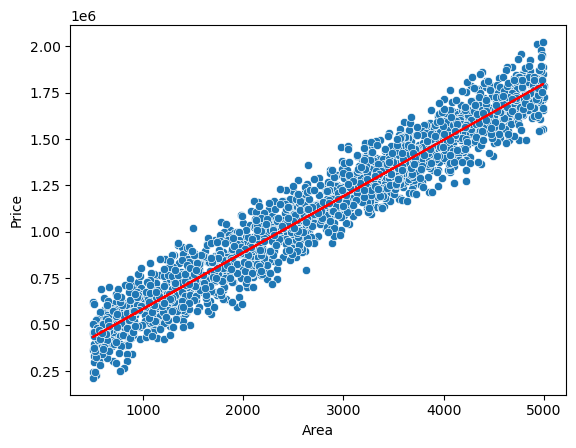

In [21]:
#Graph
sns.scatterplot(x = 'Area' , y = 'Price' , data = df)
plt.plot(X_test , model.predict(X_test) , color = 'red')
print("House Price Prediction : Area vs Price")

In [22]:
new_house=np.array([[2000]])
predicted_price=model.predict(new_house)
print("Predicted House Prices:",predicted_price[0])

Predicted House Prices: 888285.4319331972
